In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

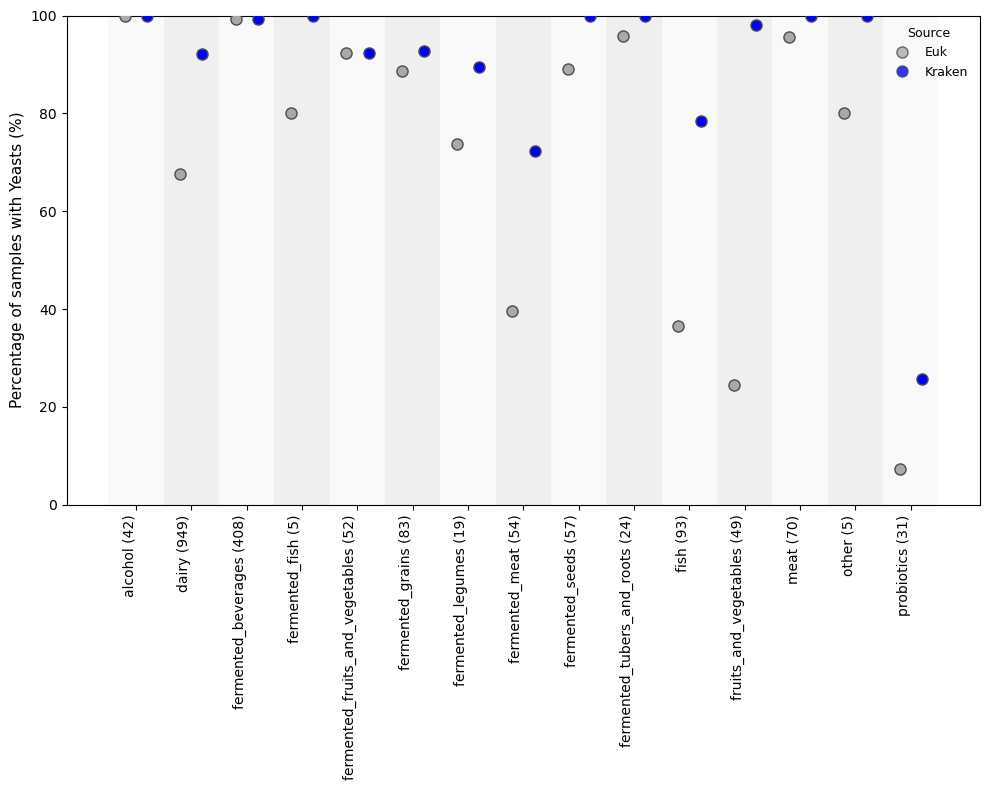

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_euk = pd.read_csv("food_fungi_distribution_eukdetect.tsv", sep="\t")
df_kraken = pd.read_csv("food_fungi_distribution_K2_B.tsv", sep="\t")


df_euk = df_euk.rename(columns={"label": "category_label"})
df_kraken = df_kraken.rename(columns={"label": "category_label"})

df_euk = df_euk[["category_label", "Yeast", "n_samples"]]
df_kraken = df_kraken[["category_label", "Yeast", "n_samples"]]


df_euk["category"] = df_euk["category_label"].str.extract(r"^(.*?)\s*\(")[0].str.strip()
df_kraken["category"] = df_kraken["category_label"].str.extract(r"^(.*?)\s*\(")[0].str.strip()


df_euk["Source"] = "Euk"
df_kraken["Source"] = "Kraken"
combined_df = pd.concat([df_euk, df_kraken], ignore_index=True)

plot_df = combined_df[["category", "Source", "Yeast", "n_samples"]].copy()
plot_df = plot_df.rename(columns={"Yeast": "Yeast Percentage"})


category_order = sorted(plot_df["category"].unique())

source_colors = {
    "Euk": "darkgray",
    "Kraken": "blue"
}

plt.figure(figsize=(10, 8))
ax = sns.stripplot(
    data=plot_df,
    x="category",
    y="Yeast Percentage",
    hue="Source",
    order=category_order,
    palette=source_colors,
    size=8,
    jitter=True,
    edgecolor="0.3",
    linewidth=1,
    dodge=True
)


for i in range(len(category_order)):
    color = "#f0f0f0" if i % 2 == 0 else "#d9d9d9"
    ax.axvspan(i - 0.5, i + 0.5, facecolor=color, alpha=0.4, zorder=-1)


sample_map = dict(zip(df_euk["category"], df_euk["n_samples"]))
xtick_labels = [f"{cat} ({sample_map.get(cat, 0)})" for cat in category_order]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=90, ha="right")
ax.set_ylim(0, 100)
plt.ylabel("Percentage of samples with Yeasts (%)", fontsize=11)
plt.xlabel("") 
ax.grid(False)


leg = plt.legend(
    title="Source",
    loc="upper right",
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    bbox_to_anchor=(0.999, 0.999)
)

for lh in leg.legend_handles:
    lh.set_alpha(0.8)

plt.tight_layout()
plt.show()
#plot_df.to_csv("Figure12_e.tsv", sep='\t')